In [ ]:
import sys; print(sys.path)
import matplotlib.pyplot as plt
import neurokit2 as nk
import mne
import pathlib
import matplotlib
import pandas as pd
import numpy as np


In [25]:
train_df = pd.read_csv('data/train.csv')
train_df.head()

,crew,experiment,time,seat,eeg_fp1,eeg_f7,eeg_f8,eeg_t4,eeg_t6,eeg_t5,...,eeg_c4,eeg_p4,eeg_poz,eeg_c3,eeg_cz,eeg_o2,ecg,r,gsr,event
0,1,CA,0.011719,1,-5.28545,26.775801,-9.527310,-12.793200,16.717800,33.737499,...,37.368999,17.437599,19.201900,20.5968,-3.95115,14.507600,-4520.0,817.705994,388.829987,A
1,1,CA,0.015625,1,-2.42842,28.430901,-9.323510,-3.757230,15.969300,30.443600,...,31.170799,19.399700,19.689501,21.3547,1.33212,17.750200,-4520.0,817.705994,388.829987,A
2,1,CA,0.019531,1,10.67150,30.420200,15.350700,24.724001,16.143101,32.142799,...,-12.012600,19.396299,23.171700,22.4076,1.53786,22.247000,-4520.0,817.705994,388.829987,A
3,1,CA,0.023438,1,11.45250,25.609800,2.433080,12.412500,20.533300,31.494101,...,18.574100,23.156401,22.641199,19.3367,2.54492,18.998600,-4520.0,817.705994,388.829987,A
4,1,CA,0.027344,1,7.28321,25.942600,0.113564,5.748000,19.833599,28.753599,...,6.555440,22.754700,22.670300,20.2932,1.69962,22.812799,-4520.0,817.705994,388.829987,A


In [26]:
from mne import create_info
from mne.io import RawArray


eeg_fp1_data = train_df['eeg_fp1'].values
eeg_t5_data = train_df['eeg_t5'].values
eeg_o2_data = train_df['eeg_o2'].values
eeg_fz_data = train_df['eeg_fz'].values


data = np.vstack([eeg_fp1_data, eeg_t5_data, eeg_o2_data, eeg_fz_data])


sfreq = 256
ch_names = ['Fp1', 'T5', 'O2', 'Fz']
ch_types = ['eeg'] * len(ch_names)
info = create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
raw = RawArray(data, info)
print(raw)


Creating RawArray with float64 data, n_channels=4, n_times=4867421
    Range : 0 ... 4867420 =      0.000 ... 19013.359 secs
Ready.
<RawArray | 4 x 4867421 (19013.4 s), ~148.5 MB, data loaded>


In [27]:
print(eeg_fp1_data)

[ -5.28545   -2.42842   10.6715   ... -42.078499  20.536301 -12.2307  ]


In [28]:
print(eeg_fp1_data.shape)

(4867421,)


In [29]:
print(raw)


<RawArray | 4 x 4867421 (19013.4 s), ~148.5 MB, data loaded>


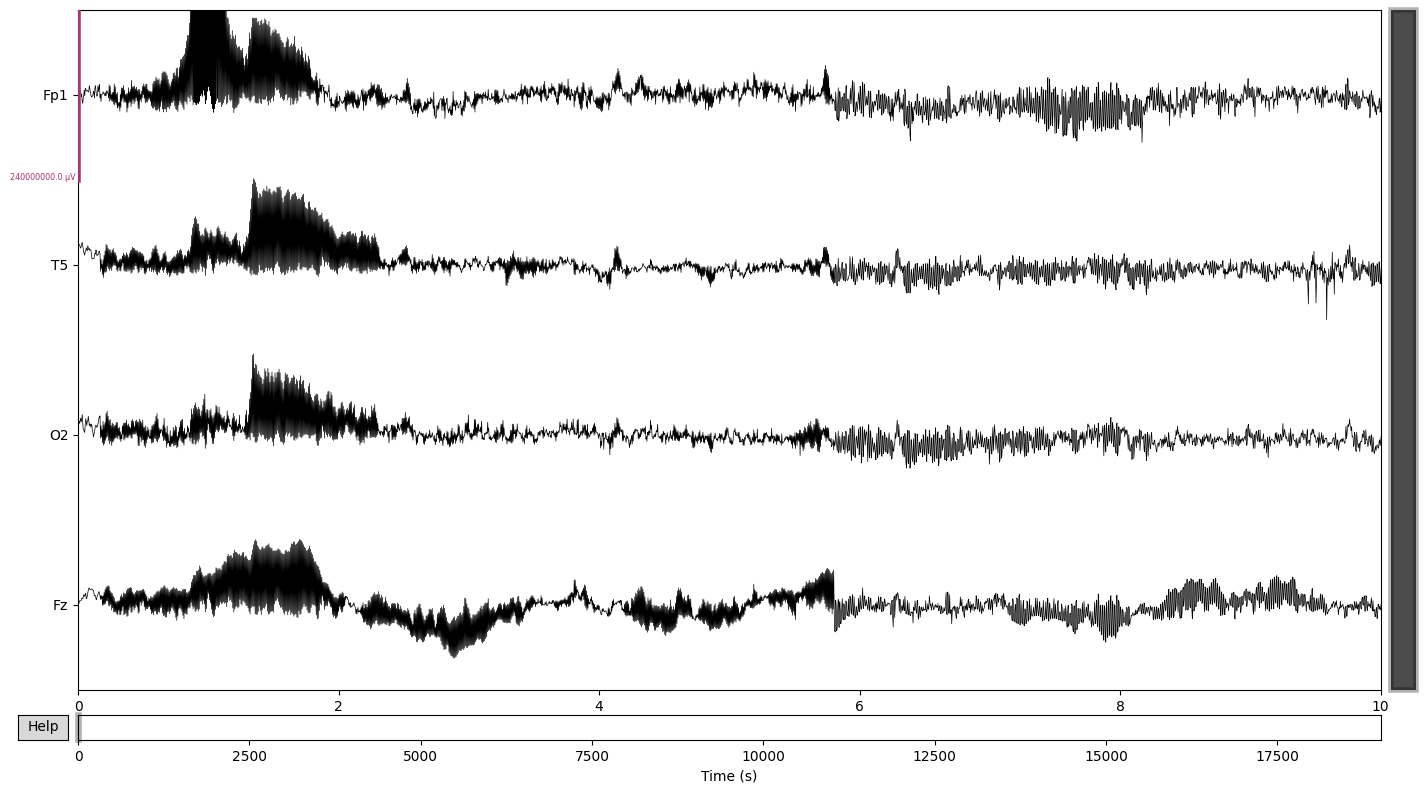

In [ ]:
scalings = {'eeg': 120}
raw.plot(scalings=scalings, block=True);  



Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 845 samples (3.301 s)

Fitting ICA to data using 4 channels (please be patient, this may take a while)
Selecting by number: 4 components
Fitting ICA took 13.7s.


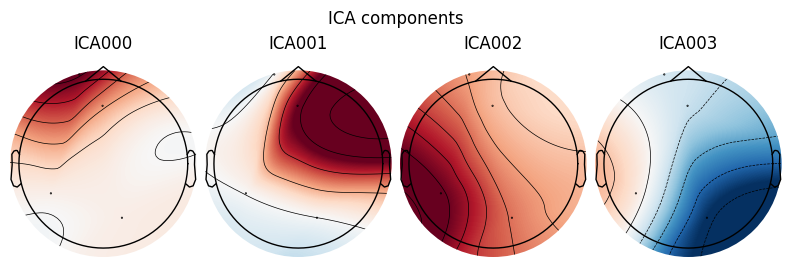

Applying ICA to Raw instance
    Transforming to ICA space (4 components)
    Zeroing out 2 ICA components
    Projecting back using 4 PCA components


In [ ]:
from mne.preprocessing import ICA

raw_filtered = raw.copy().filter(l_freq=1.0, h_freq=40.0)

montage = mne.channels.make_standard_montage("standard_1020")
raw_filtered.set_montage(montage)


ica = ICA(n_components=4, random_state=42, max_iter=800)

ica.fit(raw_filtered)

ica.plot_components()

ica.exclude = [0, 1]  
raw_cleaned = ica.apply(raw_filtered)

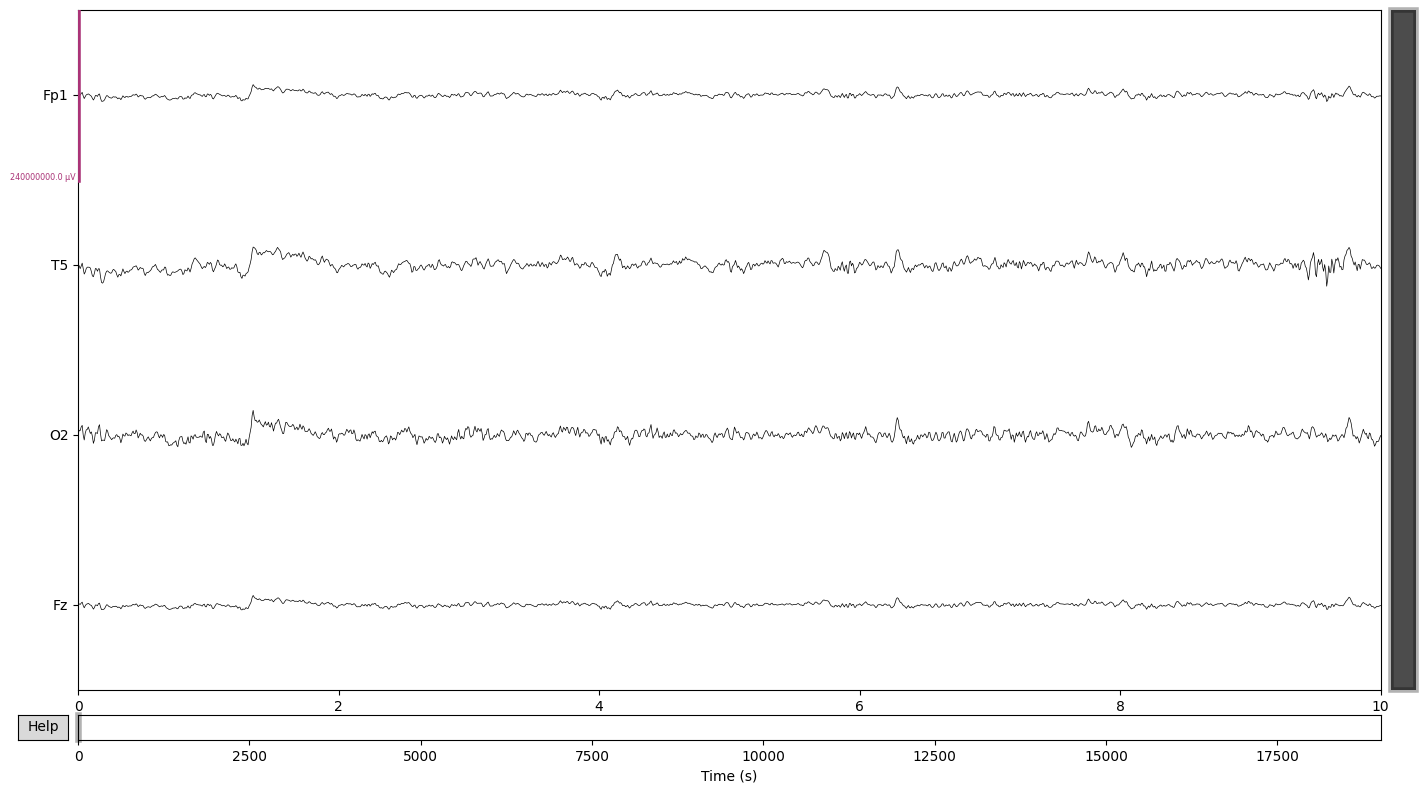

In [33]:
scalings = {'eeg': 120}
raw_cleaned.plot(scalings=scalings, block=True);  

In [48]:
from scipy.stats import skew, kurtosis, entropy
from scipy.signal import welch
from scipy.integrate import simpson
import pywt  
from mne import io

# Load the saved file
raw_loaded = io.read_raw_fif('eeg_preprocessed_raw.fif', preload=True)
eeg_data = raw_loaded.get_data()  

window_size = 5  # 5 seconds
step_size = 1    # Updated every second
fs = raw_loaded.info['sfreq']  # Sampling frequency
window_samples = int(window_size * fs)
step_samples = int(step_size * fs)
n_channels, n_samples = eeg_data.shape


windows = []
for start in range(0, n_samples - window_samples + 1, step_samples):
    end = start + window_samples
    windows.append(eeg_data[:, start:end])
    

Opening raw data file eeg_preprocessed_raw.fif...
    Range : 0 ... 4867420 =      0.000 ... 19013.359 secs
Ready.
Reading 0 ... 4867420  =      0.000 ... 19013.359 secs...


In [68]:
def extract_summary_statistics(signal):
    mean = np.mean(signal)
    variance = np.var(signal)
    skewness = skew(signal)
    kurt = kurtosis(signal)
    cv = np.std(signal) / mean if mean != 0 else 0
    quantiles = np.percentile(signal, [0.5, 2.5, 25, 50, 75, 97.5, 99.5])
    iqr = quantiles[4] - quantiles[2]
    pdf, _ = np.histogram(signal, bins=50, density=True)
    signal_entropy = entropy(pdf)
    auc = simpson(signal)
    return [mean, variance, skewness, kurt, cv, *quantiles, iqr, signal_entropy, auc]


In [67]:
def extract_psd(signal, fs, fmin=1, fmax=40):

    freqs, psd = welch(signal, fs, nperseg=fs*2)  
    

    freq_resolution = freqs[1] - freqs[0] 
    desired_freqs = np.arange(fmin, fmax + 1, freq_resolution)
    psd_dict = dict(zip(freqs, psd))
    

    psd_1hz_bins = []
    for f in range(fmin, fmax + 1):
        closest_freq = min(psd_dict.keys(), key=lambda x: abs(x - f))
        psd_1hz_bins.append(psd_dict[closest_freq])
    
    return psd_1hz_bins



In [66]:
def extract_wavelet_features(signal, wavelet='db4', level=5):
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    flattened_coeffs = np.hstack(coeffs)  
    return flattened_coeffs[:33] 


In [73]:
features_list = []
for window in windows:
    window_features = []
    for ch_idx in range(n_channels):
        channel_data = window[ch_idx]
        
        # Summary statistics
        summary_stats = extract_summary_statistics(channel_data)  # List of 15 features
        
        # PSD
        psd_features = extract_psd(channel_data, fs)  # List of 40 features
        
        # Wavelet decomposition
        wavelet_features = extract_wavelet_features(channel_data)  # List of 40 features
        
        # Store features for this channel as separate lists
        channel_features = [summary_stats, psd_features, wavelet_features]
        window_features.append(channel_features)  # Append to window features
    
    features_list.append(window_features)  # Append all channel features for this window



In [74]:
import pickle

with open('features_list.pkl', 'wb') as f:
    pickle.dump(features_list, f)


In [78]:
window_idx = 7
channel_idx = 1

summary_stats = features_list[window_idx][channel_idx][0]
psd_features = features_list[window_idx][channel_idx][1]
wavelet_features = features_list[window_idx][channel_idx][2]

print("Summary Stats:", summary_stats)
print("PSD Features:", psd_features)
print("Wavelet Features:", wavelet_features)


Summary Stats: [np.float64(0.3646326112895622), np.float64(42.48156964614807), np.float64(-0.32569457460337387), np.float64(1.7387394691350044), np.float64(17.874947293543507), np.float64(-21.200392484664917), np.float64(-12.7480984210968), np.float64(-3.6815239787101746), np.float64(0.7172112166881561), np.float64(4.347377300262451), np.float64(12.536560320854168), np.float64(18.947205200195352), np.float64(8.028901278972626), np.float64(3.1452437363824375), np.float64(467.20362062690157)]
PSD Features: [np.float64(4.010255665502014), np.float64(3.1264430241536267), np.float64(2.1852373465486545), np.float64(2.760649888479365), np.float64(1.0201765235679594), np.float64(0.37820036065072327), np.float64(1.240997302887209), np.float64(3.6460054222736353), np.float64(1.6102961856742708), np.float64(2.7912405583904265), np.float64(1.2354323557349627), np.float64(1.1200697425720028), np.float64(0.8649476959280736), np.float64(1.910794973006947), np.float64(0.4338499388948645), np.float64(1

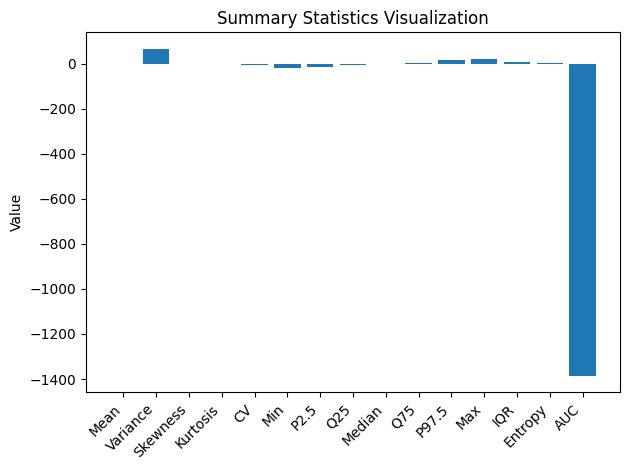

In [99]:
import matplotlib.pyplot as plt


summary_stats = features_list[0][1][0]  # Example window 0, channel 1, summary stats
stats_labels = ['Mean', 'Variance', 'Skewness', 'Kurtosis', 'CV', 'Min', 'P2.5', 'Q25', 
                'Median', 'Q75', 'P97.5', 'Max', 'IQR', 'Entropy', 'AUC']

plt.bar(stats_labels, summary_stats)
plt.xticks(rotation=45, ha='right')
plt.title('Summary Statistics Visualization')
plt.ylabel('Value')
plt.tight_layout()
plt.show()


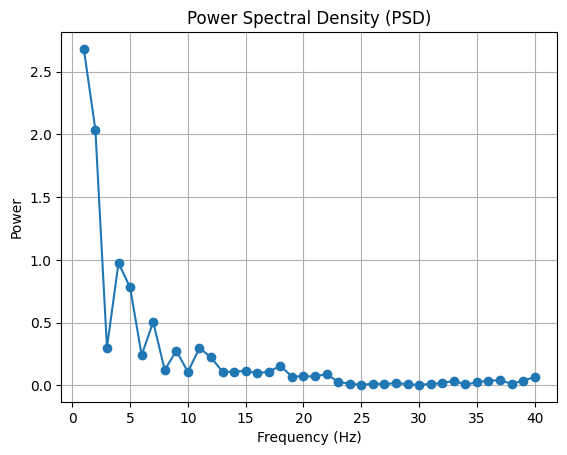

In [91]:
# Example: Visualize PSD for one channel in one window
psd_features = features_list[0][0][1]  # Example window 0, channel 0, PSD features
freqs = list(range(1, len(psd_features) + 1))  # 1 Hz to 40 Hz bins

plt.plot(freqs, psd_features, marker='o')
plt.title('Power Spectral Density (PSD)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power')
plt.grid(True)
plt.show()


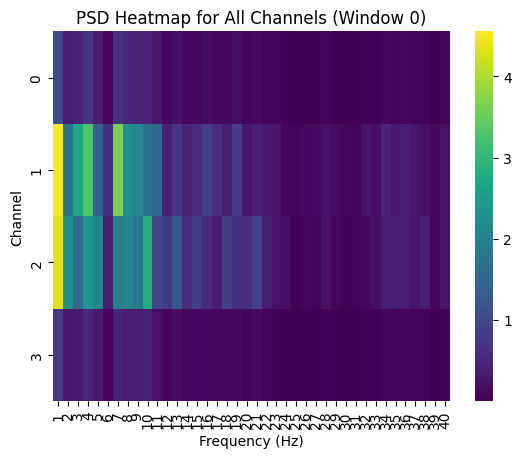

In [ ]:
import numpy as np
import seaborn as sns


psd_all_channels = [features_list[5][ch][1] for ch in range(len(features_list[0]))] 
sns.heatmap(np.array(psd_all_channels), cmap='viridis', xticklabels=freqs)
plt.title('PSD Heatmap for All Channels (Window 0)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Channel')
plt.show()

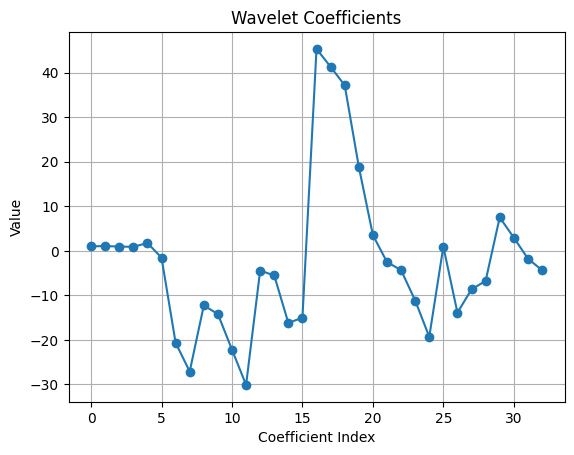

In [94]:

wavelet_features = features_list[0][0][2]  # Example window 0, channel 0, wavelet features

plt.plot(wavelet_features, marker='o')
plt.title('Wavelet Coefficients')
plt.xlabel('Coefficient Index')
plt.ylabel('Value')
plt.grid(True)
plt.show()